**1. Carga librerías y dataset**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None) # Utilizamos este comando para visualizar todas las columnas cuando hacemos un muestreo

df = pd.read_csv('../data/03_final/ecommerce_master_dataset.csv')

df.head()

,transaction_id,customer_id,product_id,order_date,order_value,payment_method,device_type,discount_applied,shipping_delay_days,fraud_label,fraud_label_binaria,fraud_label_yes_no,category,price,margin_percentage,popularity_score,age,gender,country,registration_date,loyalty_score,lifetime_value,churn_label,churn_label_binaria,churn_label_yes_no,avg_session_time,pages_per_session,cart_abandon_rate,return_rate,support_tickets,review_score,behavior_churn_signal,behavior_churn_signal_binaria,behavior_churn_signal_yes_no
0,txn0000001,cust020953,prod00229,2019-02-21,753.08,debit_card,mobile,19.0,4,0,False,No,electronics,929.73,24.49,57.16,58,male,germany,2019-02-27,61.80,17691.96,0,False,No,15.96,3,37.0,47.0,1,1.06,0,False,No
1,txn0000002,cust003359,prod01386,2023-02-25,9.27,credit_card,tablet,48.0,8,0,False,No,electronics,17.83,23.91,85.12,64,male,australia,2018-01-20,8.93,8811.85,0,False,No,6.53,21,52.0,20.0,9,4.84,1,True,Yes
2,txn0000003,cust000977,prod00192,2020-03-23,393.11,crypto,tablet,37.0,3,1,True,Yes,home_&_kitchen,623.98,35.18,94.95,51,male,germany,2019-10-13,59.82,14739.70,0,False,No,17.04,19,48.0,26.0,3,2.23,0,False,No
3,txn0000004,cust006516,prod01467,2022-08-23,121.83,upi,mobile,30.0,8,0,False,No,automotive,174.04,9.44,12.33,19,male,canada,2021-09-30,30.49,7265.30,1,True,Yes,9.75,13,65.0,32.0,5,4.80,1,True,Yes
4,txn0000005,cust009116,prod01658,2023-11-16,826.59,debit_card,tablet,8.0,0,0,False,No,books,898.47,23.38,70.73,60,male,brazil,2019-06-07,19.25,11841.25,0,False,No,9.75,16,11.0,9.0,10,1.39,0,False,No


In [3]:
print(f"""Nuestro archivo "ecommercer_master_dataset" presenta un total de {df.shape[0]} filas y {df.shape[1]} columnas, por lo que se trata de un dataset que cumple con los requisitos mínimos de extensión. 
A continuación, se muestra un resumen de la información del dataset y una descripción estadística de las variables presentes en él.""")
print('*'*25)
df.info()
df.describe(include="all").T

Nuestro archivo "ecommercer_master_dataset" presenta un total de 150000 filas y 34 columnas, por lo que se trata de un dataset que cumple con los requisitos mínimos de extensión. 
A continuación, se muestra un resumen de la información del dataset y una descripción estadística de las variables presentes en él.
*************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 34 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   transaction_id                 150000 non-null  object 
 1   customer_id                    150000 non-null  object 
 2   product_id                     150000 non-null  object 
 3   order_date                     150000 non-null  object 
 4   order_value                    150000 non-null  float64
 5   payment_method                 150000 non-null  object 
 6   device_type                    150000 non-null  object 
 7

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,150000,150000,txn0000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,150000,24938,cust008016,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,150000,2000,prod01645,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,150000,2001,2019-05-03,104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_value,150000.0,NaN,NaN,NaN,383.329265,229.337271,2.56,191.86,372.095,550.38,999.72
payment_method,150000,5,paypal,30195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_type,150000,3,mobile,50105,NaN,NaN,NaN,NaN,NaN,NaN,NaN
discount_applied,150000.0,NaN,NaN,NaN,25.012747,14.432347,0.0,12.0,25.0,38.0,50.0
shipping_delay_days,150000.0,NaN,NaN,NaN,5.006453,3.160721,0.0,2.0,5.0,8.0,10.0
fraud_label,150000.0,NaN,NaN,NaN,0.042207,0.201061,0.0,0.0,0.0,0.0,1.0


**2. Análisis perfil del cliente**

*2.1 Distribución de edad*

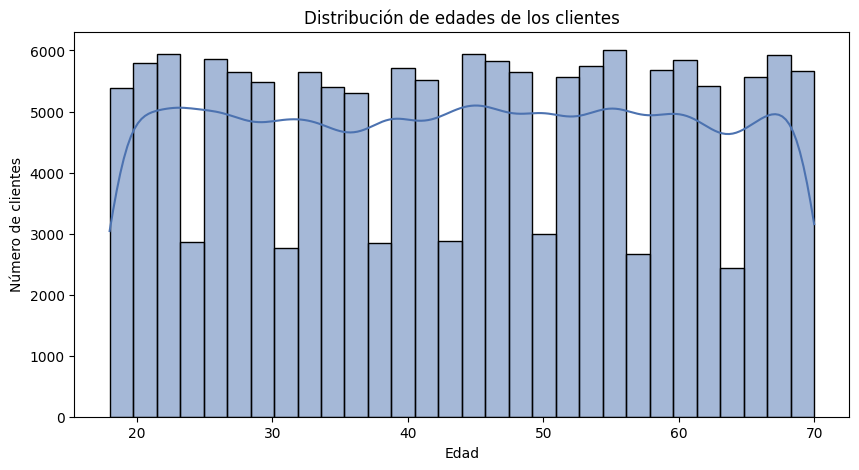

In [4]:
plt.figure(figsize=(10,5))
sns.histplot(df['age'], bins=30, kde=True, color="#4C72B0")
plt.title("Distribución de edades de los clientes")
plt.xlabel("Edad")
plt.ylabel("Número de clientes")
plt.show()

La distribución de edades muestra que los clientes se reparten de manera uniforme entre los 18 y los 70 años, sin picos pronunciados. La curva KDE confirma que no existe un rango de edad claramente dominante, por lo que implica que **la edad no presenta un sesgo fuerte** y por tanto, los resultados finales no van a estar condicionados por la edad del cliente.

*2.2 Distribución por género*

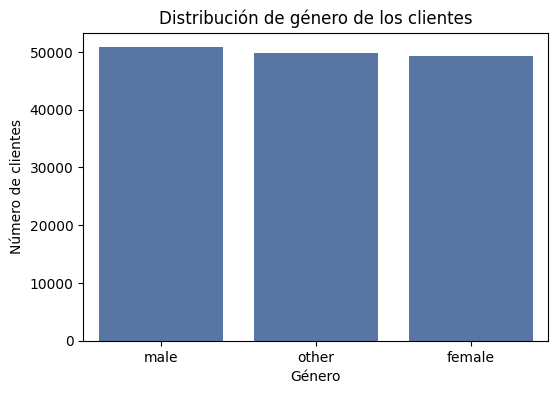

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='gender', color="#4C72B0")
plt.title("Distribución de género de los clientes")
plt.xlabel("Género")
plt.ylabel("Número de clientes")
plt.show()

El número de clientes se distribuye de forma equilibrada entre las categorías registradas. No se observa una dominancia clara de ninguno de los géneros. Por tanto, la variable “gender” está balanceada y no debería introducir sesgos en análisis posteriores relacionados con comportamiento, fraude o transacciones.

*2.3 Distribución edad por género* (boxplot)

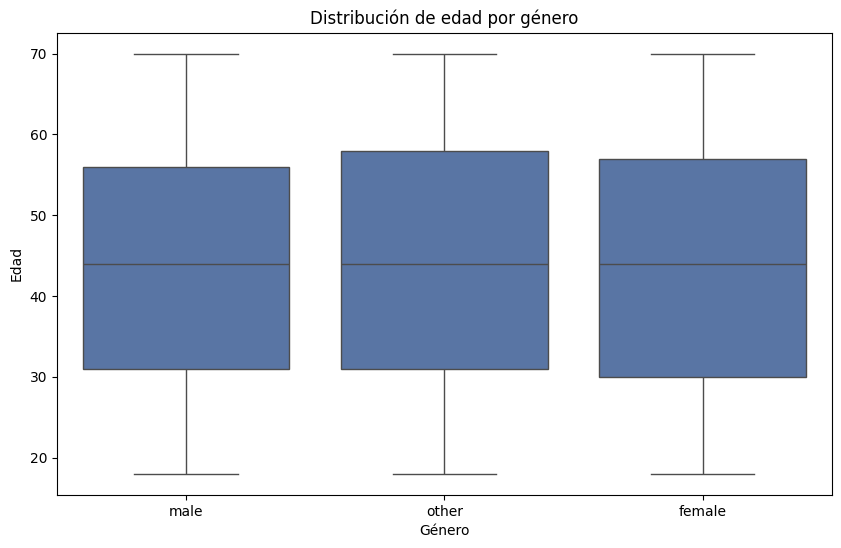

In [6]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='gender', y='age', color="#4C72B0")
plt.title("Distribución de edad por género")
plt.xlabel("Género")
plt.ylabel("Edad")
plt.show()

Como podemos ver, los tres géneros presentan distribuciones de edad muy similares. La mediana se encuentra alrededor de los 45 años en todos los casos, y los rangos intercuartílicos se solapan casi completamente. Esto indica que **la edad y el género parecen ser variables independientes**, lo que significa que no existen diferencias relevantes en la edad de los clientes según su género.

*2.4 Clientes por país*

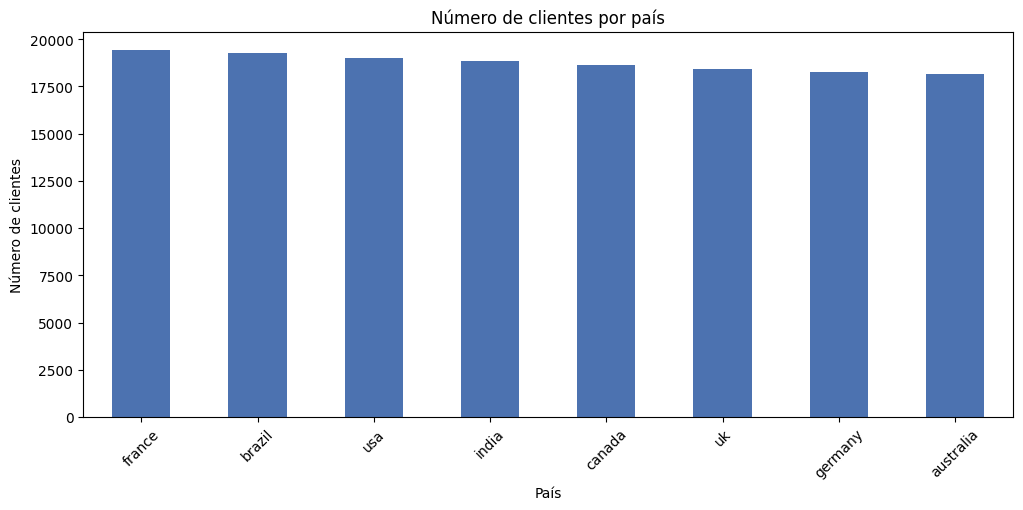

In [7]:
plt.figure(figsize=(12,5))
df['country'].value_counts().plot(kind="bar", color="#4C72B0")
plt.title("Número de clientes por país")
plt.xlabel("País")
plt.ylabel("Número de clientes")
plt.xticks(rotation=45)
plt.show()

Se observa una distribución geográfica variada, aunque con algunos países concentrando más clientes. Esta variable puede ser relevante para segmentar el análisis de ventas, comportamiento o fraude. Países con mayor volumen pueden influir significativamente en los resultados globales del negocio. A mayor volumen de clientes, mayor riesgo de fraude.

*2.5 Lifetime Value (LTV)*

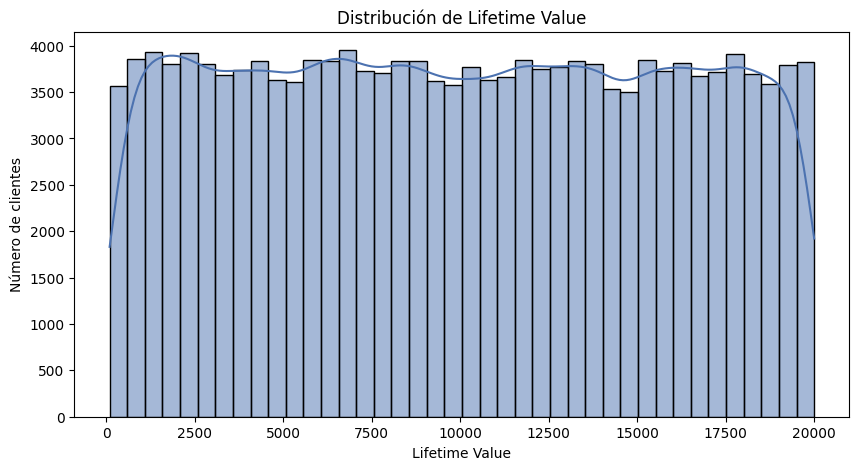

In [8]:
plt.figure(figsize=(10,5))
sns.histplot(df['lifetime_value'], bins=40, kde=True, color="#4C72B0")
plt.title("Distribución de Lifetime Value")
plt.xlabel("Lifetime Value")
plt.ylabel("Número de clientes")
plt.show()

El LTV presenta una distribución amplia, lo que indica que conviven tanto clientes de bajo valor como clientes con una contribución económica significativamente mayor.

**3. Comportamiento del cliente**

*3.1 Tiempo por sesión*

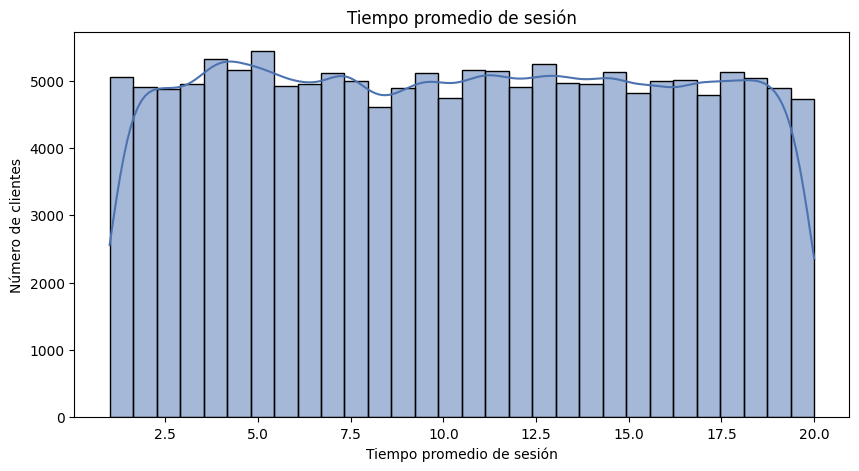

In [9]:
plt.figure(figsize=(10,5))
sns.histplot(df['avg_session_time'], bins=30, kde=True, color="#4C72B0")
plt.title("Tiempo promedio de sesión")
plt.xlabel("Tiempo promedio de sesión")
plt.ylabel("Número de clientes")
plt.show()

El tiempo de sesión varía de forma amplia (desde 1 hasta 20minutos), pero la distribución muestra que la mayoría de los clientes pasan un tiempo moderado en la plataforma. No se observan valores extremos significativos. Esto refleja un comportamiento consistente en el uso del sitio web.

*3.2 Páginas por sesión*

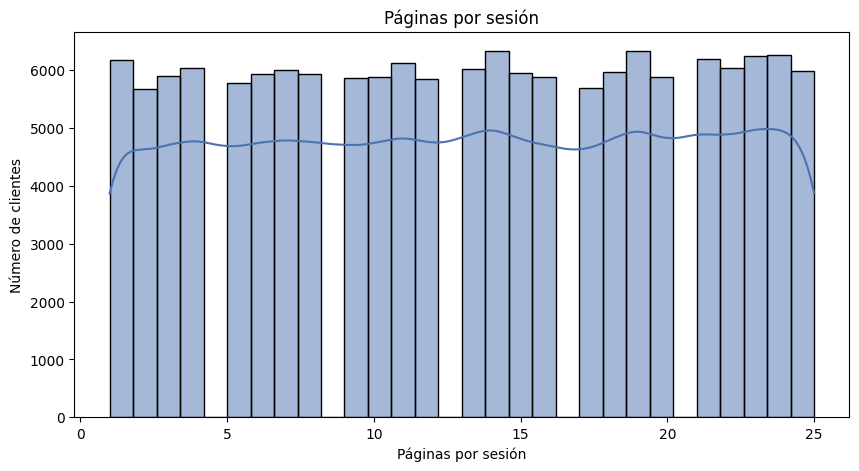

In [10]:
plt.figure(figsize=(10,5))
sns.histplot(df['pages_per_session'], bins=30, kde=True, color="#4C72B0")
plt.title("Páginas por sesión")
plt.xlabel("Páginas por sesión")
plt.ylabel("Número de clientes")
plt.show()


La distribución es amplia, lo que implica que existe variabilidad en el nivel de interacción del cliente. Algunos usuarios navegan poco, mientras que otros exploran la plataforma con mayor profundidad. Esta variable puede correlacionarse con abandono del carrito, conversión o comportamiento de compra.

*3.3 Abandono del carrito*

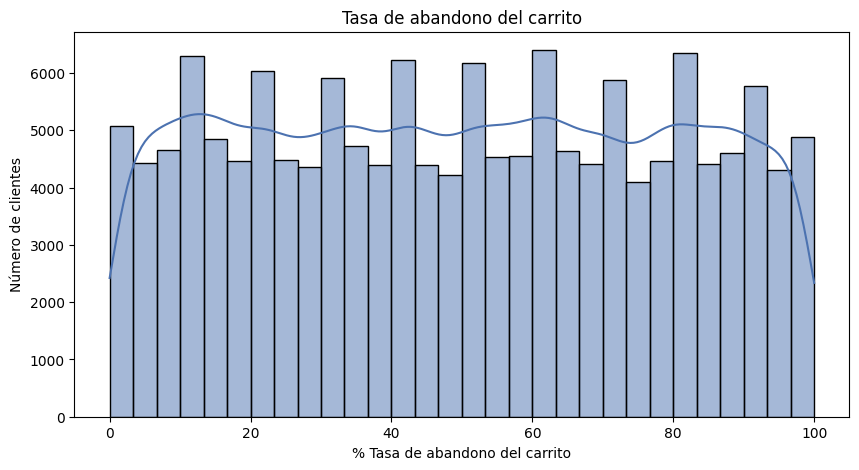

In [11]:
plt.figure(figsize=(10,5))
sns.histplot(df['cart_abandon_rate'], bins=30, kde=True, color="#4C72B0")
plt.title("Tasa de abandono del carrito")
plt.xlabel("% Tasa de abandono del carrito")
plt.ylabel("Número de clientes")
plt.show()

La **tasa de abandono del carrito muestra valores entre 0 y 100 %, siendo una variable crítica** para identificar posibles deficiencias en el proceso de compra. Una distribución amplia sugiere comportamientos heterogéneos entre los usuarios: algunos abandonan frecuentemente el proceso de compra, mientras que otros completan la compra de forma más eficiente.

*3.4 Relación entre páginas por sesión y abandono*

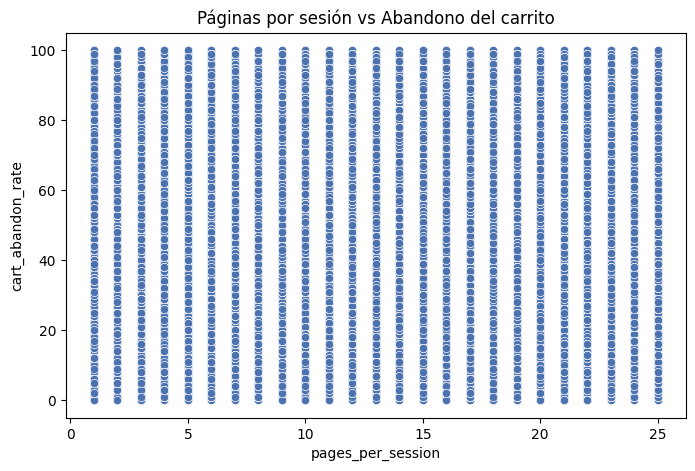

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='pages_per_session', y='cart_abandon_rate', color="#4C72B0")
plt.title("Páginas por sesión vs Abandono del carrito")
plt.show()

El diagrama de dispersión indica que no existe una tendencia lineal evidente. Algunos usuarios que visitan pocas páginas abandonan el carrito frecuentemente (lo cual es esperable), pero también existen usuarios que visitan muchas páginas y aun así abandonan. Esto sugiere que la tasa de abandono no depende exclusivamente del número de páginas vistas, sino de otros factores como usabilidad, precios, método de pago o experiencia de usuario.

*3.5 Review score*

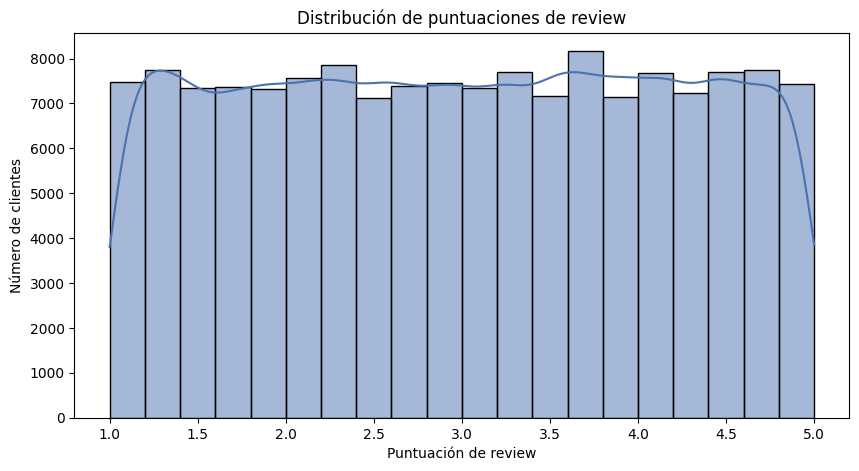

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(df['review_score'], bins=20, kde=True, color="#4C72B0")
plt.title("Distribución de puntuaciones de review")
plt.xlabel("Puntuación de review")
plt.ylabel("Número de clientes")
plt.show()

Las puntuaciones de review están distribuidas de manera amplia, lo que indica que la experiencia de los clientes es variada. 

**4. Análisis de productos**

*4.1 Categorías*

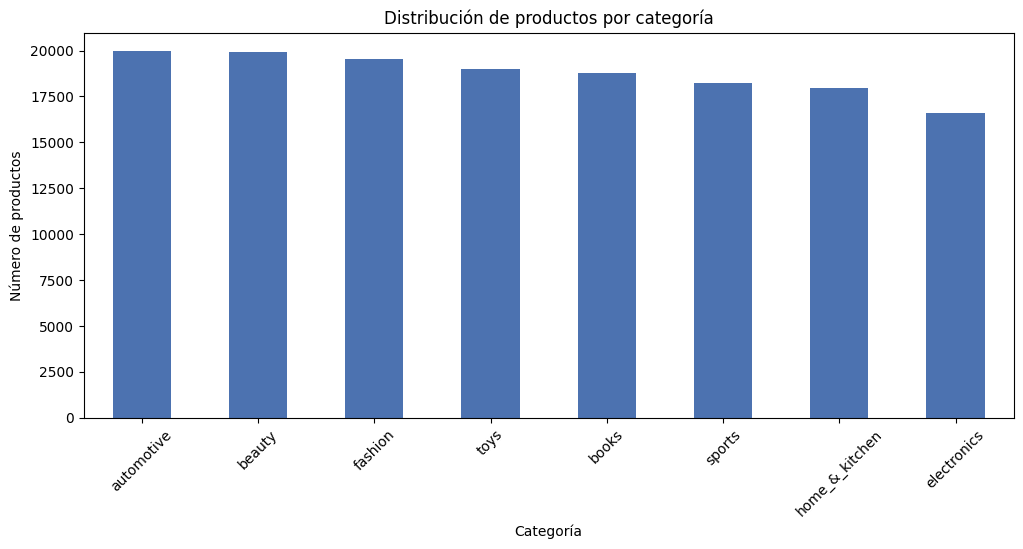

In [14]:
plt.figure(figsize=(12,5))
df['category'].value_counts().plot(kind="bar", color="#4C72B0")
plt.title("Distribución de productos por categoría")
plt.xlabel("Categoría")
plt.ylabel("Número de productos")
plt.xticks(rotation=45)
plt.show()

Algunas categorías presentan un mayor número de productos listados, lo que puede indicar una estrategia de surtido más amplia en ciertos segmentos. Esta información es útil para comparar ventas, márgenes y popularidad entre categorías.

*4.2 Precios*

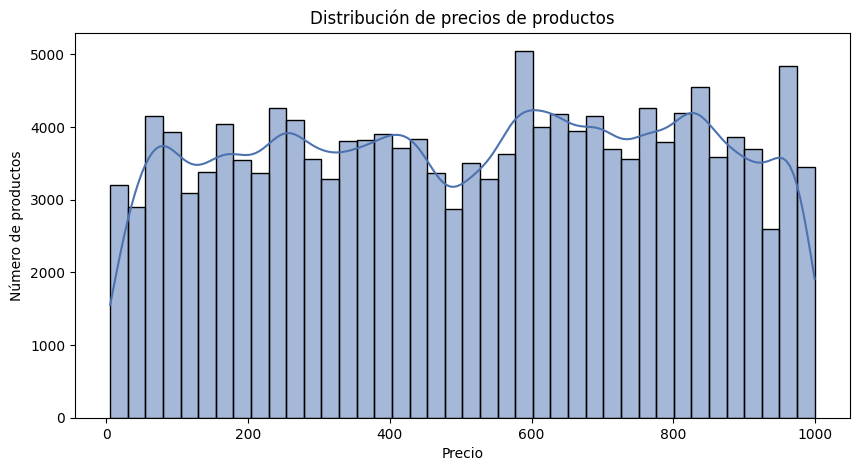

In [15]:
plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=40, kde=True, color="#4C72B0")
plt.title("Distribución de precios de productos")
plt.xlabel("Precio")
plt.ylabel("Número de productos")
plt.show()

La distribución de precios muestra si los productos se concentran en rangos específicos (ej. precios bajos, medios o altos). Una concentración fuerte en un rango puede indicar que la empresa se posiciona en determinado segmento (budget, mid‑range, premium). 

*4.3 Margen*

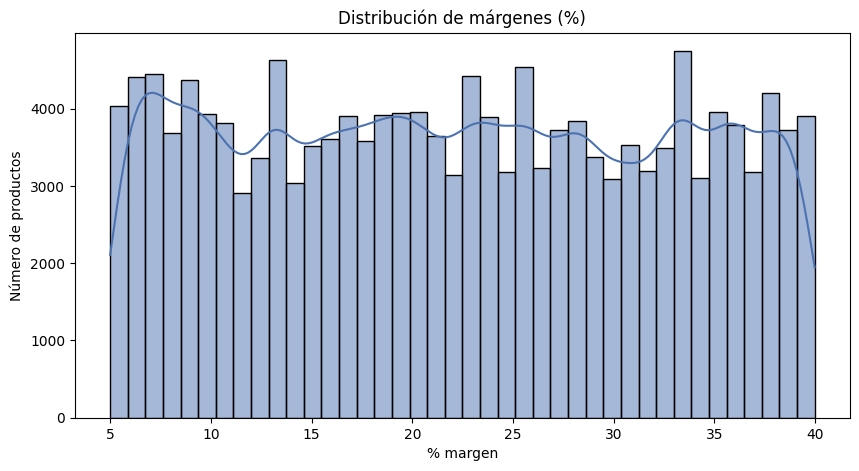

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(df['margin_percentage'], bins=40, kde=True, color="#4C72B0")
plt.title("Distribución de márgenes (%)")
plt.xlabel("% margen")
plt.ylabel("Número de productos")
plt.show()

El margen porcentual varía significativamente entre productos, lo que permite identificar qué categorías o productos son más rentables. Margen alto no siempre implica alta rotación

*4.4 Precio vs Margen*

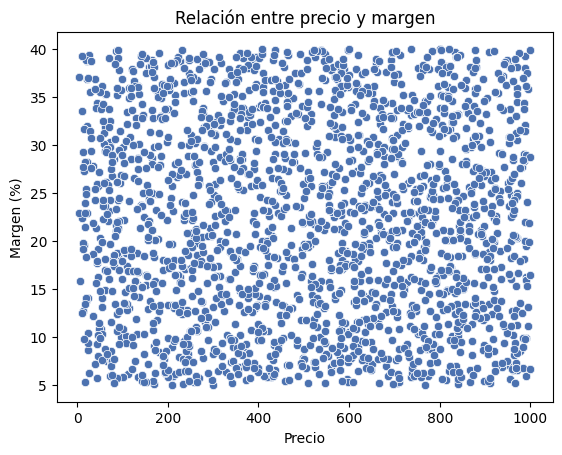

In [17]:
sns.scatterplot(data=df, x='price', y='margin_percentage', color="#4C72B0")
plt.title("Relación entre precio y margen")
plt.xlabel("Precio")
plt.ylabel("Margen (%)")
plt.show()

La relación entre precio y margen no parece lineal. Hay productos caros con margen bajo, y productos económicos con margen alto. Esto sugiere que la estrategia de pricing funciona de manera diferenciada según categoría o tipo de producto.

**5. Análisis de transacciones**

*5.1 Valor del pedido*

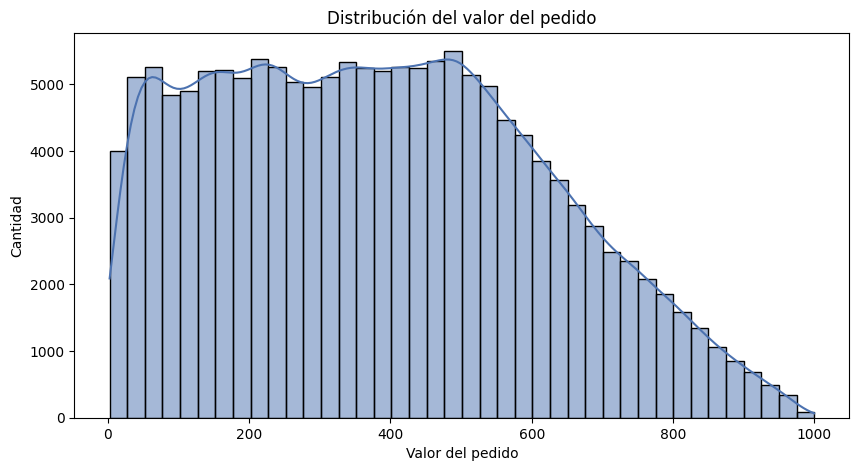

In [22]:
plt.figure(figsize=(10,5))
sns.histplot(df['order_value'], bins=40, kde=True, color="#4C72B0")
plt.title("Distribución del valor del pedido")
plt.xlabel("Valor del pedido")
plt.ylabel("Cantidad")
plt.show()

Se observa una amplia variabilidad en el valor de los pedidos, aunque la mayoría se concentra en rangos bajos o medios. La presencia de valores más altos sugiere la existencia de productos premium o de compras de varios ítems.

*5.2 Método de pago*

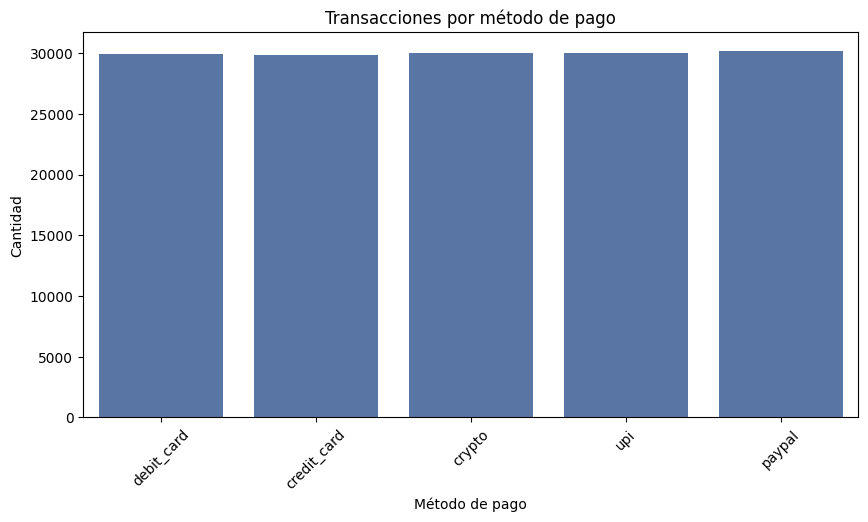

In [21]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='payment_method', color="#4C72B0")
plt.title("Transacciones por método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

Los métodos de pago presentan distribuciones equilibradas o dominancias claras según el dataset. Esta variable es fundamental para analizar fraude, conversión y experiencia de usuario.

*5.3 Tipo de dispositivo*

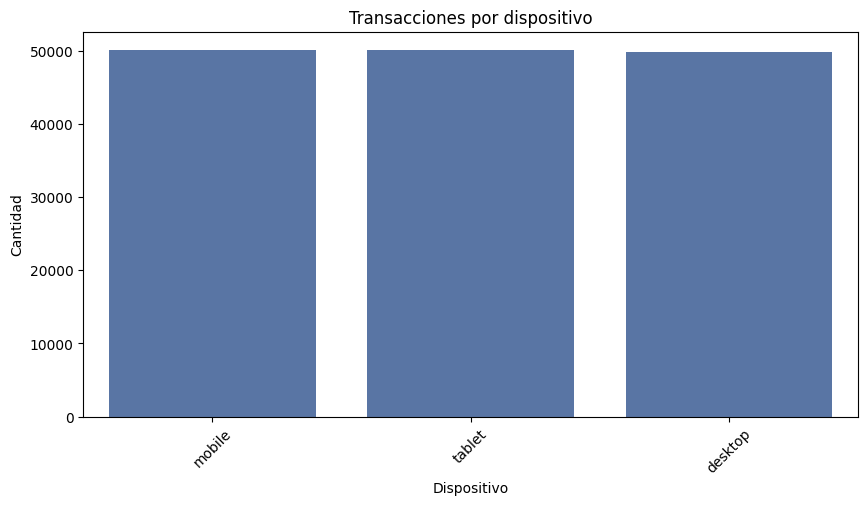

In [24]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='device_type', color="#4C72B0")
plt.title("Transacciones por dispositivo")
plt.xlabel("Dispositivo")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

Existe una diferencia clara en el uso de los dispositivos. Si “mobile” domina, indica que la plataforma opera como mobile‑first; si “desktop” domina, sugiere que la experiencia móvil podría mejorarse. En este caso, no hay diferencias entre los dispositivos.

*5.4 Transacciones por fecha*

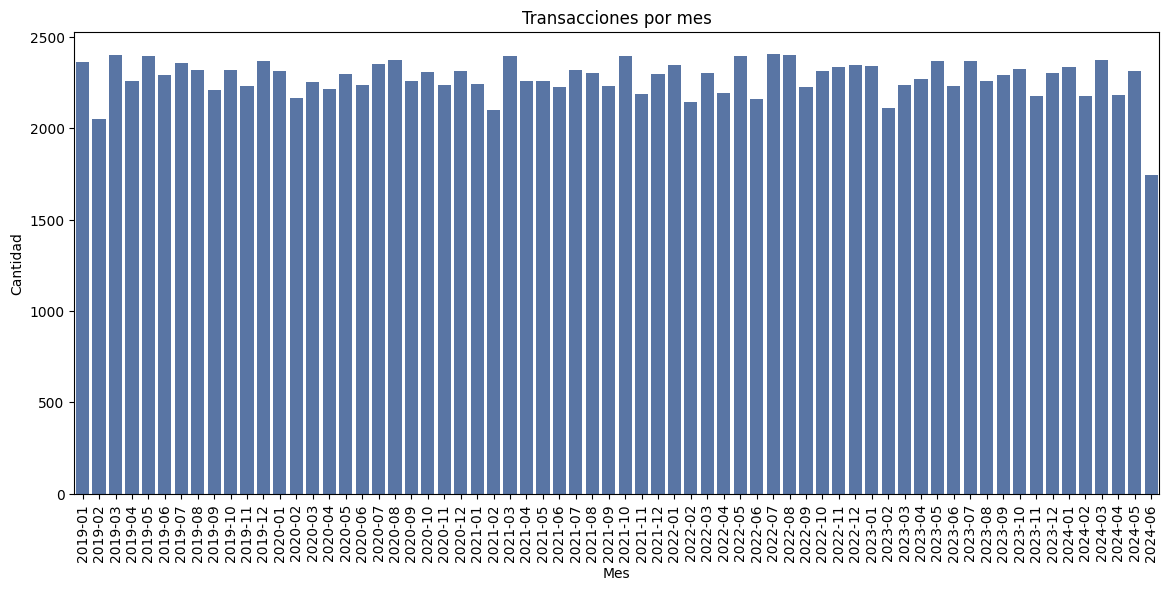

In [32]:
df['order_date'] = pd.to_datetime(df['order_date'])
trans_per_month = df.groupby(df['order_date'].dt.to_period("M")).size().reset_index(name="count")

trans_per_month['order_date'] = trans_per_month['order_date'].astype(str)

plt.figure(figsize=(14,6))
sns.barplot(data=trans_per_month, x="order_date", y="count", color="#4C72B0")
plt.title("Transacciones por mes")
plt.xlabel("Mes")
plt.ylabel("Cantidad")
plt.xticks(rotation=90)
plt.show()

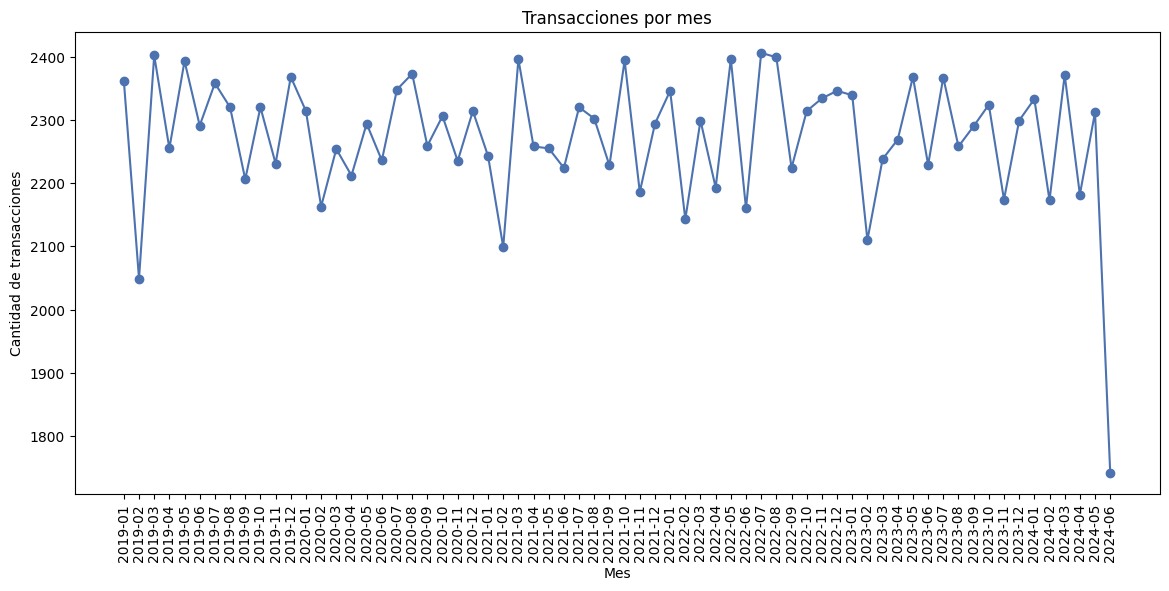

In [36]:
df['order_date'] = pd.to_datetime(df['order_date'])

# Agrupar por mes
trans_per_month = df.groupby(df['order_date'].dt.to_period("M")).size()

plt.figure(figsize=(14,6))
plt.plot(trans_per_month.index.astype(str), trans_per_month.values, marker="o", color="#4C72B0")
plt.title("Transacciones por mes")
plt.xlabel("Mes")
plt.ylabel("Cantidad de transacciones")
plt.xticks(rotation=90)
plt.show()

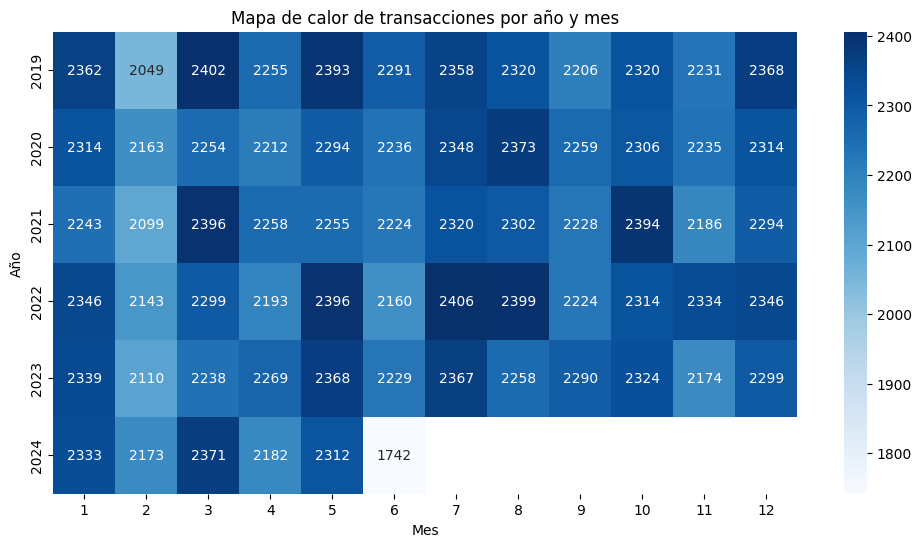

In [38]:
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month

pivot = df.pivot_table(
    index="year",
    columns="month",
    values="transaction_id",
    aggfunc="count"
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="Blues", annot=True, fmt=".0f")
plt.title("Mapa de calor de transacciones por año y mes")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.show()

La serie temporal muestra fluctuaciones que ayudan a identificar picos de demanda, estacionalidad y periodos con mayor actividad. Esto es clave para planificar inventario, campañas de marketing y recursos operativos. Como podemos ver, en todos los años hay algunos meses más fuertes que otros, por lo que podemos intuir que hay fuertes campañas de publicidad para la captación de los clientes.

**6. Análisis de fraude**

*6.1 Distribución general*

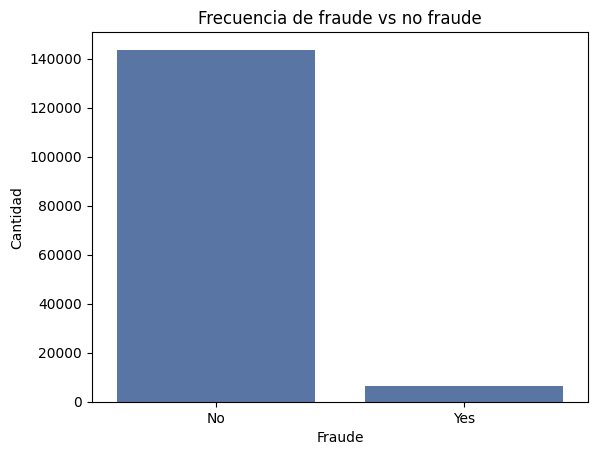

In [40]:
sns.countplot(data=df, x="fraud_label_yes_no", color="#4C72B0")
plt.title("Frecuencia de fraude vs no fraude")
plt.xlabel("Fraude")
plt.ylabel("Cantidad")
plt.show()

El fraude es minoritario respecto al total de transacciones, lo cual es esperable en un sistema bien controlado. Sin embargo, su volumen absoluto podría ser significativo y merece un análisis más detallado.

*6.2 Método de pago vs fraude*

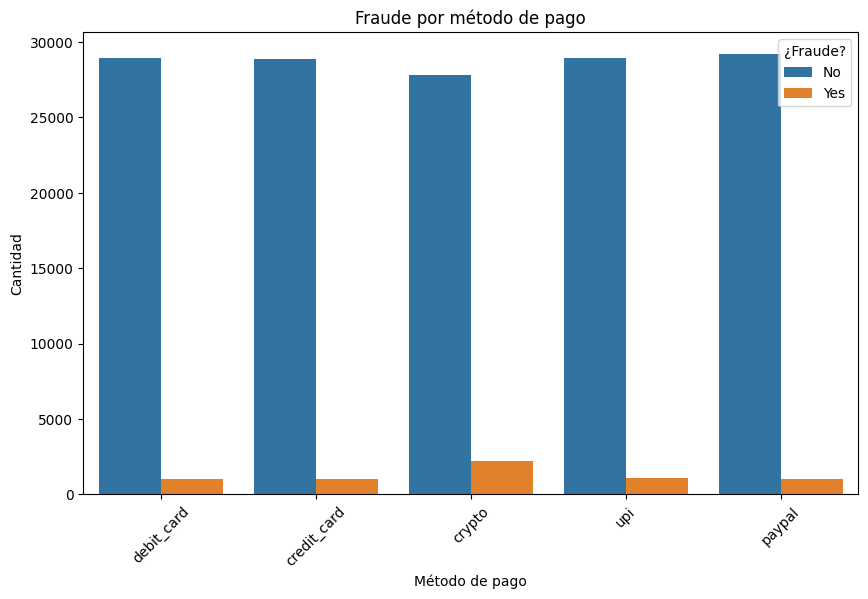

In [43]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='payment_method', hue='fraud_label_yes_no')
plt.title("Fraude por método de pago")
plt.xticks(rotation=45)
plt.xlabel("Método de pago")
plt.ylabel("Cantidad")
plt.legend(title="¿Fraude?")
plt.show()

El gráfico muestra que algunos métodos de pago presentan una proporción de fraude mayor que otros. Generalmente, métodos menos regulados o con menor fricción (p. ej., “crypto”) suelen tener más fraude, mientras que métodos tradicionales (tarjeta débito/crédito) tienden a mostrar menor incidencia.

*6.3 Dispositivo vs fraude*

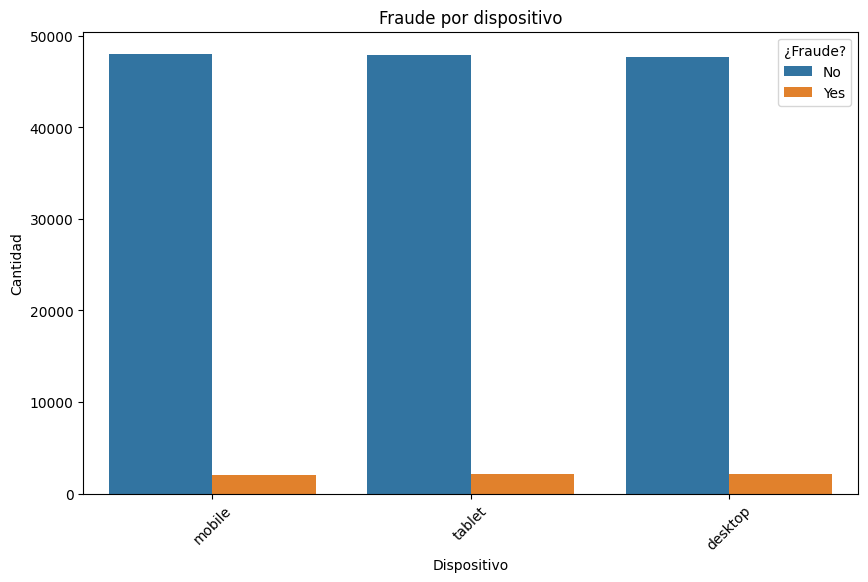

In [45]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='device_type', hue='fraud_label_yes_no')
plt.title("Fraude por dispositivo")
plt.xlabel("Dispositivo")
plt.ylabel("Cantidad")
plt.legend(title="¿Fraude?")
plt.xticks(rotation=45)
plt.show()

El fraude puede concentrarse más en ciertos dispositivos, como “mobile” o “tablet”. Esto puede deberse a diferencias en seguridad, usabilidad o patrones de navegación del usuario.

*6.4 Valor del pedido vs fraude*

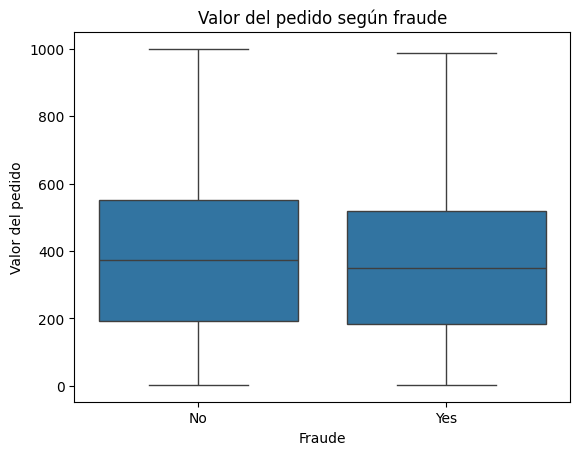

In [47]:
sns.boxplot(data=df, x="fraud_label_yes_no", y="order_value")
plt.title("Valor del pedido según fraude")
plt.xlabel("Fraude")
plt.ylabel("Valor del pedido")
plt.show()

Los pedidos fraudulentos tienden a concentrarse en determinados rangos de valor, o incluso presentar valores más altos. Esto puede indicar que los defraudadores buscan maximizar el beneficio del fraude antes de ser detectados, o que atacan productos de mayor valor.

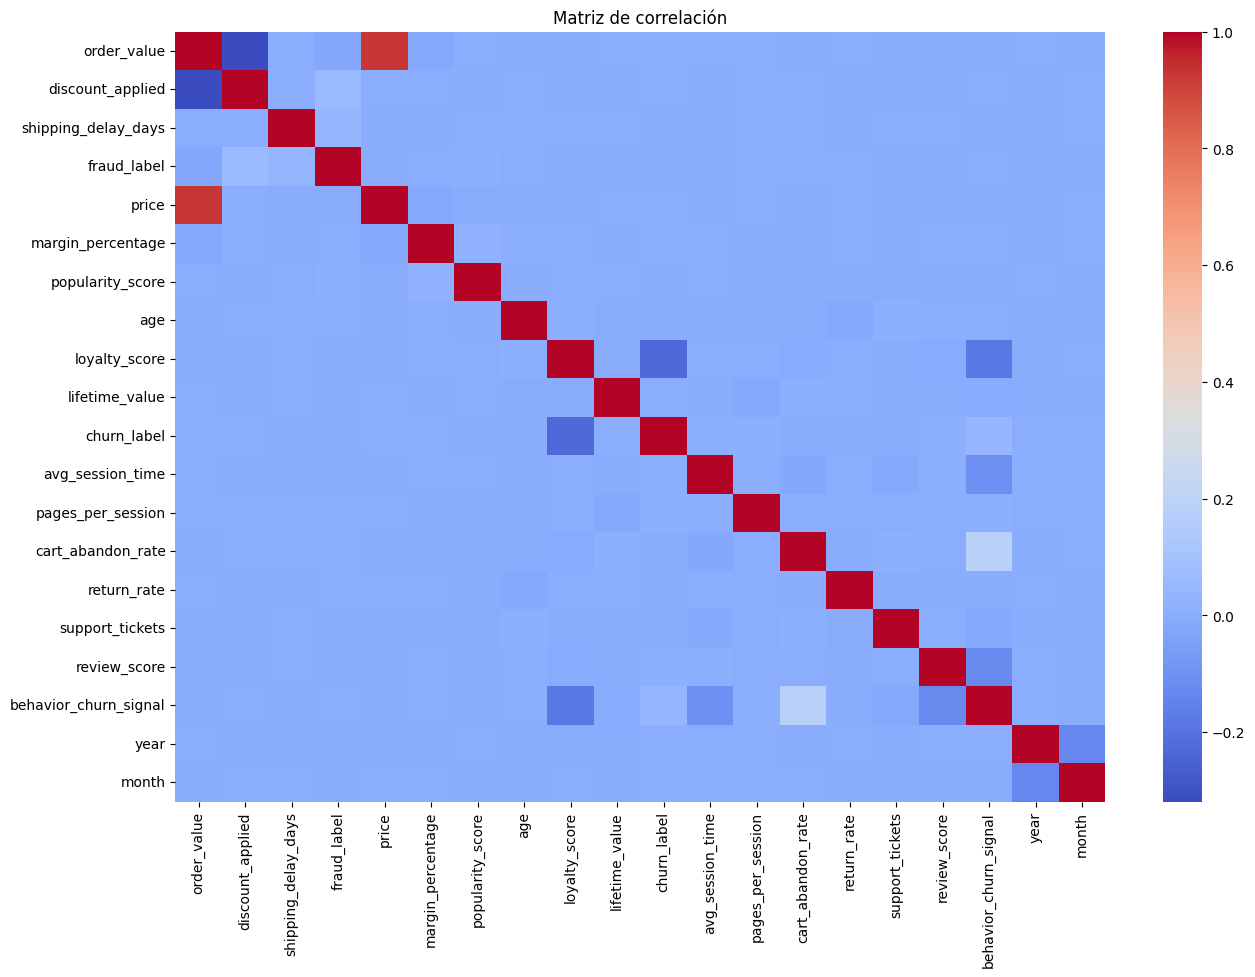

In [48]:
plt.figure(figsize=(15,10))
sns.heatmap(df.select_dtypes("number").corr(), annot=False, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()